# Testing a basic green field model with danish data

In [187]:
using JuMP
using Clp
using Plots
using DataFrames, CSV

In [214]:
include("helper_functions.jl")

get_result (generic function with 2 methods)

<h3>1. Loading Data

In [215]:
time_series = CSV.read("demand_and_cf_2030.csv",DataFrame)


Row,Column1,pv_aggregated_capacity_factor,onshore_aggregated_capacity_factor,offshore_aggregated_capacity_factor,Date,aggregated_demand,T
,Int64,Float64,Float64,Float64,String31,Float64,Int64
1,0,0.0,0.779246,0.891849,2030-01-01 00:00:00,4834.11,1
2,1,0.0,0.813199,0.913412,2030-01-01 01:00:00,4675.02,2
3,2,0.0,0.838057,0.92467,2030-01-01 02:00:00,4582.6,3
4,3,0.0,0.861093,0.937683,2030-01-01 03:00:00,4523.58,4
5,4,0.0,0.884924,0.951262,2030-01-01 04:00:00,4496.03,5
6,5,0.0,0.900207,0.956141,2030-01-01 05:00:00,5128.56,6
7,6,0.0,0.906981,0.955651,2030-01-01 06:00:00,5935.79,7
8,7,0.0,0.91464,0.955402,2030-01-01 07:00:00,6522.27,8
9,8,0.014,0.923904,0.960392,2030-01-01 08:00:00,6559.37,9


In [216]:
tech_data = CSV.read("tech_data2030.csv",DataFrame)


Row,Column1,Technology,Dispachable,Lifetime,Nominal investment (*total) [MEUR/MW_e],Variable O&M (*total) [EUR/MWh_e],Fixed O&M (*total) [EUR/MW_e/y],Year,Specific investment [M€/MWh Output],Avaliability (hours)
,Int64,String31,Int64,Int64,Float64,Float64?,Float64,Int64,Float64?,Float64?
1,0,Onshore turbines,0,30,1.14664,1.97518,16662.7,2030,missing,missing
2,2,Offshore trubines fixed,0,30,2.39313,3.4467,34000.0,2030,missing,missing
3,4,Offshore trubines floating,0,30,3.55813,6.21842,62000.0,2030,missing,missing
4,6,Utility scale PV,0,40,0.38,missing,9500.0,2030,missing,missing
5,8,"Biogas, Basic plant, small",1,20,8.4096,150.0,74.28,2030,0.96,8760.0
6,10,"Biogas, Basic plant, large",1,20,8.9352,150.0,62.53,2030,1.02,8760.0


* We choose to only look at fixed offshore turbines and large biogas plants, and thus remove floating turbines and small biogass plants. 
* Because, in at least the case of wind turbines it has to correspond to the columsn in the capacity factor dataset and there we only have onshore and offshore wind. 
* The small biogass plant might be included but Ieave it out for now for simplicity:

In [217]:
tech_data = tech_data[(tech_data.Technology .!= "Offshore trubines floating") .& (tech_data.Technology .!= "Biogas, Basic plant, small"),:]

Row,Column1,Technology,Dispachable,Lifetime,Nominal investment (*total) [MEUR/MW_e],Variable O&M (*total) [EUR/MWh_e],Fixed O&M (*total) [EUR/MW_e/y],Year,Specific investment [M€/MWh Output],Avaliability (hours)
,Int64,String31,Int64,Int64,Float64,Float64?,Float64,Int64,Float64?,Float64?
1,0,Onshore turbines,0,30,1.14664,1.97518,16662.7,2030,missing,missing
2,2,Offshore trubines fixed,0,30,2.39313,3.4467,34000.0,2030,missing,missing
3,6,Utility scale PV,0,40,0.38,missing,9500.0,2030,missing,missing
4,10,"Biogas, Basic plant, large",1,20,8.9352,150.0,62.53,2030,1.02,8760.0


Could not find any maginal cost data on biomass, so i based the number 150 euro per MWH in a deep reseach, we can play around with this and try to base it on a reliable source. Link to Deep research:             
            https://chatgpt.com/s/dr_691348a52be881918e38dbe3568ae27a


<h3>2. Defining sets based on the Data:

* We dont inplement any storage technologies in this model, but we could of course try to implement it later.

In [218]:
T = 1:size(time_series, 1) |> collect

8760-element Vector{Int64}:
    1
    2
    3
    4
    5
    6
    7
    8
    9
   10
    ⋮
 8752
 8753
 8754
 8755
 8756
 8757
 8758
 8759
 8760

In [219]:
P = tech_data[:,:Technology] |> Vector

4-element Vector{String31}:
 "Onshore turbines"
 "Offshore trubines fixed"
 "Utility scale PV"
 "Biogas, Basic plant, large"

In [220]:
DISP = tech_data[tech_data[!,:Dispachable] .== 1, :Technology]


1-element Vector{String31}:
 "Biogas, Basic plant, large"

In [221]:
NONDISP = tech_data[tech_data[!,:Dispachable] .== 0 ,:Technology]


3-element Vector{String31}:
 "Onshore turbines"
 "Offshore trubines fixed"
 "Utility scale PV"

In [222]:
demand = time_series[:,:aggregated_demand] |> Vector


8760-element Vector{Float64}:
 4834.108621688991
 4675.022638681862
 4582.597881412101
 4523.577533407546
 4496.025740263449
 5128.5648386224075
 5935.790712921192
 6522.268631031656
 6559.36754217089
 6419.858622689326
    ⋮
 6584.139593390522
 6953.803363209501
 6962.110982378417
 6847.067384065807
 6643.609221787205
 6304.7425275163205
 5861.057980849286
 5517.699287554327
 5126.595271200384

In [223]:
rename!(time_series, Dict(
    :onshore_aggregated_capacity_factor => "Onshore turbines",
    :offshore_aggregated_capacity_factor => "Offshore trubines fixed",
    :pv_aggregated_capacity_factor => "Utility scale PV"
))

Row,Column1,Utility scale PV,Onshore turbines,Offshore trubines fixed,Date,aggregated_demand,T
,Int64,Float64,Float64,Float64,String31,Float64,Int64
1,0,0.0,0.779246,0.891849,2030-01-01 00:00:00,4834.11,1
2,1,0.0,0.813199,0.913412,2030-01-01 01:00:00,4675.02,2
3,2,0.0,0.838057,0.92467,2030-01-01 02:00:00,4582.6,3
4,3,0.0,0.861093,0.937683,2030-01-01 03:00:00,4523.58,4
5,4,0.0,0.884924,0.951262,2030-01-01 04:00:00,4496.03,5
6,5,0.0,0.900207,0.956141,2030-01-01 05:00:00,5128.56,6
7,6,0.0,0.906981,0.955651,2030-01-01 06:00:00,5935.79,7
8,7,0.0,0.91464,0.955402,2030-01-01 07:00:00,6522.27,8
9,8,0.014,0.923904,0.960392,2030-01-01 08:00:00,6559.37,9


In [224]:
availability = Dict(nondisp => time_series[:,nondisp] for nondisp in NONDISP)


Dict{String31, Vector{Float64}} with 3 entries:
  "Onshore turbines"        => [0.779246, 0.813199, 0.838057, 0.861093, 0.88492…
  "Utility scale PV"        => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.014, …
  "Offshore trubines fixed" => [0.891849, 0.913412, 0.92467, 0.937683, 0.951262…

* We start with the same annuity factor as in the excersice. We can also try continuous compounding with e^rt., to test exponential discounting with, in stead of annual compounding as we use here. We can look further into if this is interesting in our case.



\begin{align*}
annuity_p &= \frac{OC_p \cdot r}{1- e^{-T_p \cdot r}} \approx OC_p \cdot \frac{1}{1-(1+r)^{-T}} = OC_p \cdot \text{annuity\_factor}
\end{align*}

In [225]:
annuity_factor(n,r) = r * (1+r)^n / (((1+r)^n)-1)

annuity_factor (generic function with 1 method)

In [226]:
interest_rate = 0.04 # Same as in lecture, try to modify it
ic_generation_cap = Dict{String, Float64}()
vc = Dict{String, Float64}()


Dict{String, Float64}()

In [227]:
for row in eachrow(tech_data)
    af = annuity_factor(row.Lifetime, interest_rate)
    ic_generation_cap[row.Technology] = row[Symbol("Nominal investment (*total) [MEUR/MW_e]")] * af
    if row.Dispachable == 1
        vc[row.Technology] = (row[Symbol("Variable O&M (*total) [EUR/MWh_e]")]/1000000)
    end
end



In [228]:
successor(arr, x) = (x == length(arr)) ? 1 : x + 1


successor (generic function with 1 method)

<h3> The Greenfield model

### The model

The model of a dispatch with capacity expansion comprises the following equations:

$$
\begin{align*}
    min~C^{gen} + C^{inv} &= \sum_{p,t} mc_{disp} \cdot G_{disp,t} 
    + \sum_{p}  annuity_p \cdot CAP^{G}_{p}\\
\end{align*}
$$

$$
\begin{align*}
    s.t. \qquad & d_{t} = \sum_p G_{disp,t} + feed\_in_{ndisp,t} - CU_t \qquad &\forall t \in T\\
    &G_{disp,t}  \leq CAP_{disp} \qquad &\forall disp \in DISP, t \in T\\
    &feed\_in_{ndisp} = ava_{ndisp,t} \cdot CAP^G_{ndisp} \qquad &\forall ndisp \in NONDISP, t \in T\\
    &G_{s,t} = CAP^G_s  &\forall s \in S\\

    &0 \leq G_{p,t},~CAP^G_p, CU_t
\end{align*}
$$

In [229]:
m = Model(Clp.Optimizer)

@variables m begin
    # variables from our dispatch model
    G[DISP, T] >= 0
    CU[T] >= 0
    
    # new variables for our investment model
    CAP_G[P] >= 0
   
end

(2-dimensional DenseAxisArray{VariableRef,2,...} with index sets:
    Dimension 1, String31["Biogas, Basic plant, large"]
    Dimension 2, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  8751, 8752, 8753, 8754, 8755, 8756, 8757, 8758, 8759, 8760]
And data, a 1×8760 Matrix{VariableRef}:
 G[Biogas, Basic plant, large,1]  …  G[Biogas, Basic plant, large,8760], 1-dimensional DenseAxisArray{VariableRef,1,...} with index sets:
    Dimension 1, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  8751, 8752, 8753, 8754, 8755, 8756, 8757, 8758, 8759, 8760]
And data, a 8760-element Vector{VariableRef}:
 CU[1]
 CU[2]
 CU[3]
 CU[4]
 CU[5]
 CU[6]
 CU[7]
 CU[8]
 CU[9]
 CU[10]
 ⋮
 CU[8752]
 CU[8753]
 CU[8754]
 CU[8755]
 CU[8756]
 CU[8757]
 CU[8758]
 CU[8759]
 CU[8760], 1-dimensional DenseAxisArray{VariableRef,1,...} with index sets:
    Dimension 1, String31["Onshore turbines", "Offshore trubines fixed", "Utility scale PV", "Biogas, Basic plant, large"]
And data, a 4-element Vector{VariableRef}:
 CAP_G[Onshore turbines]
 CAP_G[Of

In [230]:
@objective(m, Min,
    sum(vc[disp] * G[disp,t] for disp in DISP, t in T)
    + sum(ic_generation_cap[p] * CAP_G[p] for p in P)
)

0.00015 G[Biogas, Basic plant, large,1] + 0.00015 G[Biogas, Basic plant, large,2] + 0.00015 G[Biogas, Basic plant, large,3] + 0.00015 G[Biogas, Basic plant, large,4] + 0.00015 G[Biogas, Basic plant, large,5] + 0.00015 G[Biogas, Basic plant, large,6] + 0.00015 G[Biogas, Basic plant, large,7] + 0.00015 G[Biogas, Basic plant, large,8] + 0.00015 G[Biogas, Basic plant, large,9] + 0.00015 G[Biogas, Basic plant, large,10] + 0.00015 G[Biogas, Basic plant, large,11] + 0.00015 G[Biogas, Basic plant, large,12] + 0.00015 G[Biogas, Basic plant, large,13] + 0.00015 G[Biogas, Basic plant, large,14] + 0.00015 G[Biogas, Basic plant, large,15] + 0.00015 G[Biogas, Basic plant, large,16] + 0.00015 G[Biogas, Basic plant, large,17] + 0.00015 G[Biogas, Basic plant, large,18] + 0.00015 G[Biogas, Basic plant, large,19] + 0.00015 G[Biogas, Basic plant, large,20] + 0.00015 G[Biogas, Basic plant, large,21] + 0.00015 G[Biogas, Basic plant, large,22] + 0.00015 G[Biogas, Basic plant, large,23] + 0.00015 G[Biogas, Ba

In [231]:
@expression(
    m, feed_in[ndisp=NONDISP, t=T],
    availability[ndisp][t]*CAP_G[ndisp]
)


2-dimensional DenseAxisArray{AffExpr,2,...} with index sets:
    Dimension 1, String31["Onshore turbines", "Offshore trubines fixed", "Utility scale PV"]
    Dimension 2, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  8751, 8752, 8753, 8754, 8755, 8756, 8757, 8758, 8759, 8760]
And data, a 3×8760 Matrix{AffExpr}:
 0.7792462 CAP_G[Onshore turbines]         …  0.29451000000000005 CAP_G[Onshore turbines]
 0.8918492 CAP_G[Offshore trubines fixed]     0.3749554 CAP_G[Offshore trubines fixed]
 0                                            0

In [232]:
tech_data

Row,Column1,Technology,Dispachable,Lifetime,Nominal investment (*total) [MEUR/MW_e],Variable O&M (*total) [EUR/MWh_e],Fixed O&M (*total) [EUR/MW_e/y],Year,Specific investment [M€/MWh Output],Avaliability (hours)
,Int64,String31,Int64,Int64,Float64,Float64?,Float64,Int64,Float64?,Float64?
1,0,Onshore turbines,0,30,1.14664,1.97518,16662.7,2030,missing,missing
2,2,Offshore trubines fixed,0,30,2.39313,3.4467,34000.0,2030,missing,missing
3,6,Utility scale PV,0,40,0.38,missing,9500.0,2030,missing,missing
4,10,"Biogas, Basic plant, large",1,20,8.9352,150.0,62.53,2030,1.02,8760.0


In [233]:
@constraint(m, ElectricityBalance[t=T],
    sum(G[disp,t] for disp in DISP)
    + sum(feed_in[ndisp,t] for ndisp in NONDISP)
    - CU[t]
    ==
    demand[t]
)
@constraint(m, CAP_G["Onshore turbines"] >= 1000)


CAP_G[Onshore turbines] >= 1000

In [234]:
@constraint(m, MaxGeneration[disp=DISP, t=T],
    G[disp,t] <= CAP_G[disp] #må også gjøres om
)


2-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape},2,...} with index sets:
    Dimension 1, String31["Biogas, Basic plant, large"]
    Dimension 2, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  8751, 8752, 8753, 8754, 8755, 8756, 8757, 8758, 8759, 8760]
And data, a 1×8760 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape}}:
 MaxGeneration[Biogas, Basic plant, large,1] : G[Biogas, Basic plant, large,1] - CAP_G[Biogas, Basic plant, large] <= 0  …  MaxGeneration[Biogas, Basic plant, large,8760] : G[Biogas, Basic plant, large,8760] - CAP_G[Biogas, Basic plant, large] <= 0

In [235]:
optimize!(m)

Coin0506I Presolve 17520 (-1) rows, 8764 (-8760) columns and 48178 (-8761) elements
Clp0006I 0  Obj 66.310588 Primal inf 2.2483322e+08 (8760)
Clp0006I 312  Obj 333.08043 Primal inf 1.7737316e+08 (8760)
Clp0006I 624  Obj 597.28551 Primal inf 1.5906706e+08 (8760)
Clp0006I 936  Obj 862.9244 Primal inf 1.4607009e+08 (8760)
Clp0006I 1248  Obj 1127.4403 Primal inf 1.3587673e+08 (8760)
Clp0006I 1560  Obj 1386.2113 Primal inf 1.2734624e+08 (8760)
Clp0006I 1872  Obj 1651.6882 Primal inf 77256598 (6813)
Clp0006I 2184  Obj 2208.1862 Primal inf 5.2671511e+08 (5745)
Clp0006I 2496  Obj 7692.4383 Primal inf 1.6027063e+08 (3772)
Clp0006I 2768  Obj 7787.9754 Primal inf 10122869 (2487)
Clp0006I 3027  Obj 7859.5046 Primal inf 3148689.6 (1382)
Clp0006I 3276  Obj 7910.8319 Primal inf 41949865 (4205)
Clp0006I 3523  Obj 7954.9223 Primal inf 3245165.6 (1344)
Clp0006I 3765  Obj 7980.8354 Primal inf 3244988.9 (1271)
Clp0006I 3999  Obj 8042.7533 Primal inf 1177375 (1606)
Clp0006I 4311  Obj 8200.1969 Primal inf 1

* Check termination status (if =1 then our solver reached a optimal solution):

In [236]:
termination_status(m)


OPTIMAL::TerminationStatusCode = 1

<h3> Examine results:

* Dispatch for each timestep:

In [237]:
result_G = get_result(G, [:Technology, :hour])


Row,Technology,hour,value
,String31,Int64,Float64
1,"Biogas, Basic plant, large",1,0.0
2,"Biogas, Basic plant, large",2,0.0
3,"Biogas, Basic plant, large",3,0.0
4,"Biogas, Basic plant, large",4,0.0
5,"Biogas, Basic plant, large",5,0.0
6,"Biogas, Basic plant, large",6,0.0
7,"Biogas, Basic plant, large",7,0.0
8,"Biogas, Basic plant, large",8,0.0
9,"Biogas, Basic plant, large",9,0.0


In [238]:
result_G[(result_G.Technology .== "Biogas, Basic plant, large") .& (result_G.value .!= 0),:]

Row,Technology,hour,value
,String31,Int64,Float64
1,"Biogas, Basic plant, large",55,361.608
2,"Biogas, Basic plant, large",56,1481.65
3,"Biogas, Basic plant, large",57,1643.34
4,"Biogas, Basic plant, large",58,1392.95
5,"Biogas, Basic plant, large",59,1228.8
6,"Biogas, Basic plant, large",60,1255.51
7,"Biogas, Basic plant, large",61,1321.72
8,"Biogas, Basic plant, large",62,1116.49
9,"Biogas, Basic plant, large",63,1470.91


Biogass doesnt produce anything, likely because it is more expensive than renewables and has a higher marginal cost.
-> To solve this we might se a max capacity on onshore wind

CORRECTION, NOW IT ACTUALLY DOES PRODUCE, I DIVIDED VARIABLE COSTS BY 1000 000 TO GET THEM AT THE SAME LEVEL AS THE INVESTMENT COSTS

* Result renewables feed in:

In [239]:
result_feed_in = get_result(feed_in, [:Technology, :hour])


Row,Technology,hour,value
,String31,Int64,Float64
1,Onshore turbines,1,779.246
2,Offshore trubines fixed,1,19609.2
3,Utility scale PV,1,0.0
4,Onshore turbines,2,813.199
5,Offshore trubines fixed,2,20083.3
6,Utility scale PV,2,0.0
7,Onshore turbines,3,838.057
8,Offshore trubines fixed,3,20330.9
9,Utility scale PV,3,0.0


* Seems like offshore and onshore wind produces the most over the timesteps
* nevertheless we see that PV also contributes:

In [240]:
result_feed_in[(result_feed_in.Technology .== "Utility scale PV") .& (result_feed_in.value .!= 0),:]

Row,Technology,hour,value
,String31,Int64,Float64
1,Utility scale PV,9,107.233
2,Utility scale PV,10,513.185
3,Utility scale PV,11,995.732
4,Utility scale PV,12,1079.99
5,Utility scale PV,13,926.797
6,Utility scale PV,14,413.612
7,Utility scale PV,15,38.2974
8,Utility scale PV,33,666.375
9,Utility scale PV,34,1769.34


* Result curailment:

In [241]:
result_CU = get_result(CU, [:hour])


Row,hour,value
,Int64,Float64
1,1,15554.4
2,2,16221.5
3,3,16586.3
4,4,16954.5
5,5,17304.5
6,6,16794.5
7,7,15983.2
8,8,15399.0
9,9,15588.1


* Invested capacity for each technology:

In [242]:
gen_caps = DataFrame(
    technology = P,
    capacity_MW = [value(CAP_G[p]) for p in P]
)


Row,technology,capacity_MW
,String31,Float64
1,Onshore turbines,1000.0
2,Offshore trubines fixed,21987.2
3,Utility scale PV,7659.48
4,"Biogas, Basic plant, large",6904.94


In [243]:
objective_value(m)

8332.04640431923

In [244]:
dispatch_cost = sum(
    vc[disp] * value(G[disp, t])
    for disp in DISP, t in T
)
println("Dispatch (variable) cost: ", dispatch_cost)


Dispatch (variable) cost: 535.9877047228734


In [119]:
for (key, value) in availability
    println(key)
    println(sum(value))
end


Onshore turbines
2351.2974329999997
Utility scale PV
994.4070000000002
Offshore trubines fixed
3157.9071024


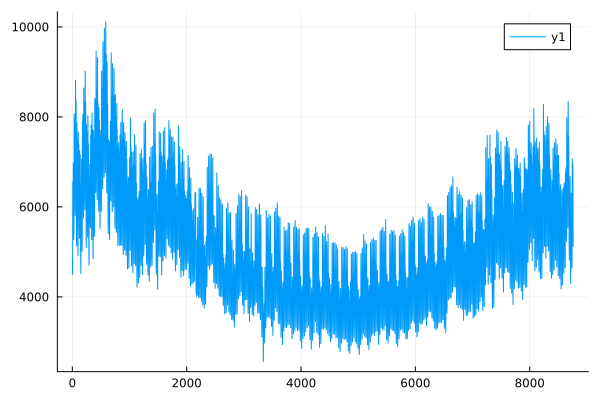

In [186]:
plot(demand)


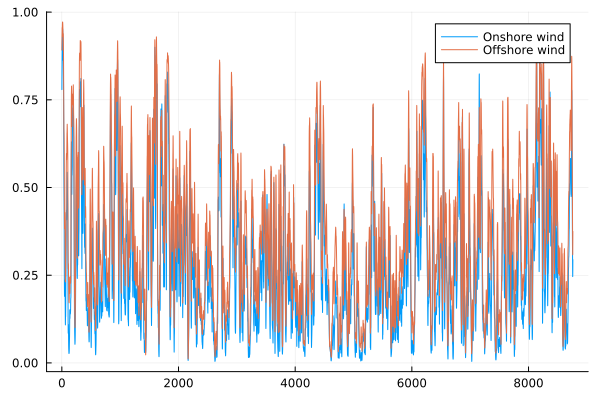

In [184]:
plot(availability["Onshore turbines"], label="Onshore wind")
plot!(availability["Offshore trubines fixed"], label="Offshore wind")


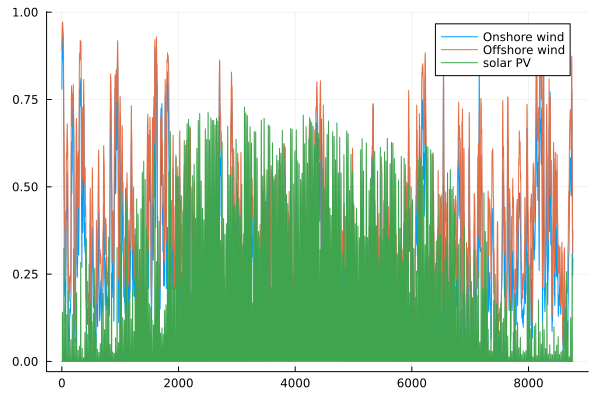

In [185]:
plot!(availability["Utility scale PV"], label="solar PV")


In [245]:
gen_investment_cost = sum(
    value(CAP_G[p]) * ic_generation_cap[p]
    for p in P
)
println("Generation investment cost: ", gen_investment_cost)


Generation investment cost: 7796.058699596357


Next steps:
* Zero onshore, not realsitic, but it makes sense that the model doesnt invest. How can we fix this to make it more realistic.
* As Alexandra said we should try to find a max cap for onshore wind and biomass based on official numbers
* include storage in batteries for example?
* Explore brownfield model

<h3> Plots

In [147]:
df_demand = DataFrame(hour=T, Technology="demand", value=demand)


Row,hour,Technology,value
,Int64,String,Float64
1,1,demand,4834.11
2,2,demand,4675.02
3,3,demand,4582.6
4,4,demand,4523.58
5,5,demand,4496.03
6,6,demand,5128.56
7,7,demand,5935.79
8,8,demand,6522.27
9,9,demand,6559.37


In [148]:
result_CU = get_result(CU, [:hour])
result_CU[!, :Technology] .= "curtailment"

result_demand = vcat(result_CU, df_demand)


Row,hour,value,Technology
,Int64,Float64,String
1,1,15291.0,curtailment
2,2,15936.6,curtailment
3,3,16283.1,curtailment
4,4,16635.8,curtailment
5,5,16969.8,curtailment
6,6,16447.3,curtailment
7,7,15629.0,curtailment
8,8,15036.9,curtailment
9,9,15218.9,curtailment


In [149]:
result_generation = vcat(result_feed_in, result_G)


Row,Technology,hour,value
,String31,Int64,Float64
1,Onshore turbines,1,0.0
2,Offshore trubines fixed,1,20125.1
3,Utility scale PV,1,0.0
4,Onshore turbines,2,0.0
5,Offshore trubines fixed,2,20611.7
6,Utility scale PV,2,0.0
7,Onshore turbines,3,0.0
8,Offshore trubines fixed,3,20865.7
9,Utility scale PV,3,0.0


In [150]:
table_gen = unstack(result_generation, :hour, :Technology, :value)


Row,hour,Onshore turbines,Offshore trubines fixed,Utility scale PV,"Biogas, Basic plant, large"
,Int64,Float64?,Float64?,Float64?,Float64?
1,1,0.0,20125.1,0.0,0.0
2,2,0.0,20611.7,0.0,0.0
3,3,0.0,20865.7,0.0,0.0
4,4,0.0,21159.3,0.0,0.0
5,5,0.0,21465.8,0.0,0.0
6,6,0.0,21575.9,0.0,0.0
7,7,0.0,21564.8,0.0,0.0
8,8,0.0,21559.2,0.0,0.0
9,9,0.0,21671.8,106.434,0.0


* Keep only nondisp and disp and drop hour:

In [151]:
table_gen = table_gen[!,[NONDISP..., DISP...]]


Row,Onshore turbines,Offshore trubines fixed,Utility scale PV,"Biogas, Basic plant, large"
,Float64?,Float64?,Float64?,Float64?
1,0.0,20125.1,0.0,0.0
2,0.0,20611.7,0.0,0.0
3,0.0,20865.7,0.0,0.0
4,0.0,21159.3,0.0,0.0
5,0.0,21465.8,0.0,0.0
6,0.0,21575.9,0.0,0.0
7,0.0,21564.8,0.0,0.0
8,0.0,21559.2,0.0,0.0
9,0.0,21671.8,106.434,0.0


In [169]:
colordict = Dict(
    "Utility scale PV" => :orange,
    "Offshore trubines fixed" => :cyan,
    "Onshore turbines" => :darkblue,
    "Biogas, Basic plant, large" => :forestgreen,
    "demand" => :darkgrey,
    "curtailment" => :red
)

Dict{String, Symbol} with 6 entries:
  "Biogas, Basic plant, large" => :forestgreen
  "Onshore turbines"           => :darkblue
  "Utility scale PV"           => :orange
  "Offshore trubines fixed"    => :cyan
  "demand"                     => :darkgrey
  "curtailment"                => :red

In [171]:
labels = names(table_gen) |> permutedims

colors = [colordict[tech] for tech in labels]
data_gen = Array(table_gen)

8760×4 Matrix{Union{Missing, Float64}}:
 0.0  20125.1     0.0    0.0
 0.0  20611.7     0.0    0.0
 0.0  20865.7     0.0    0.0
 0.0  21159.3     0.0    0.0
 0.0  21465.8     0.0    0.0
 0.0  21575.9     0.0    0.0
 0.0  21564.8     0.0    0.0
 0.0  21559.2     0.0    0.0
 0.0  21671.8   106.434  0.0
 0.0  21806.9   509.365  0.0
 ⋮                       
 0.0  11105.1     0.0    0.0
 0.0  10297.2     0.0    0.0
 0.0   9335.63    0.0    0.0
 0.0   8438.48    0.0    0.0
 0.0   7569.32    0.0    0.0
 0.0   6955.59    0.0    0.0
 0.0   7006.02    0.0    0.0
 0.0   7629.97    0.0    0.0
 0.0   8461.08    0.0    0.0

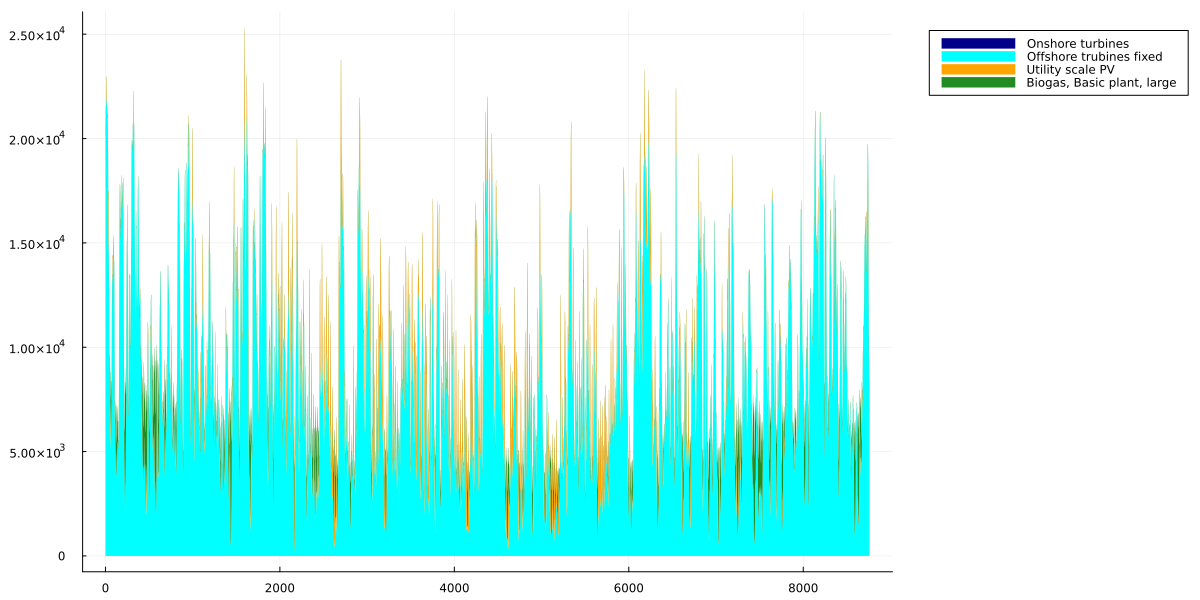

In [173]:

balance_plot = areaplot(
    data_gen,
    label=labels,
    color=colors,
    width=0,
    leg=:outertopright,
    size = (1200, 600) 
)

In [157]:
table_dem = unstack(result_demand, :hour, :Technology, :value)


Row,hour,curtailment,demand
,Int64,Float64?,Float64?
1,1,15291.0,4834.11
2,2,15936.6,4675.02
3,3,16283.1,4582.6
4,4,16635.8,4523.58
5,5,16969.8,4496.03
6,6,16447.3,5128.56
7,7,15629.0,5935.79
8,8,15036.9,6522.27
9,9,15218.9,6559.37


In [159]:
table_dem = table_dem[!,["demand", "curtailment"]]


Row,demand,curtailment
,Float64?,Float64?
1,4834.11,15291.0
2,4675.02,15936.6
3,4582.6,16283.1
4,4523.58,16635.8
5,4496.03,16969.8
6,5128.56,16447.3
7,5935.79,15629.0
8,6522.27,15036.9
9,6559.37,15218.9


In [161]:
labels2 = names(table_dem) |> permutedims
colors2 = [colordict[tech] for tech in labels2]


1×2 Matrix{Symbol}:
 :darkgrey  :red

In [162]:
replace!(labels2, [item => "" for item in intersect(labels2, labels)]...)


1×2 Matrix{String}:
 "demand"  "curtailment"

In [163]:
data_dem = -Array(table_dem)


8760×2 Matrix{Float64}:
 -4834.11  -15291.0
 -4675.02  -15936.6
 -4582.6   -16283.1
 -4523.58  -16635.8
 -4496.03  -16969.8
 -5128.56  -16447.3
 -5935.79  -15629.0
 -6522.27  -15036.9
 -6559.37  -15218.9
 -6419.86  -15896.4
     ⋮     
 -6584.14   -4520.98
 -6953.8    -3343.41
 -6962.11   -2373.52
 -6847.07   -1591.41
 -6643.61    -925.714
 -6304.74    -650.847
 -5861.06   -1144.96
 -5517.7    -2112.27
 -5126.6    -3334.49

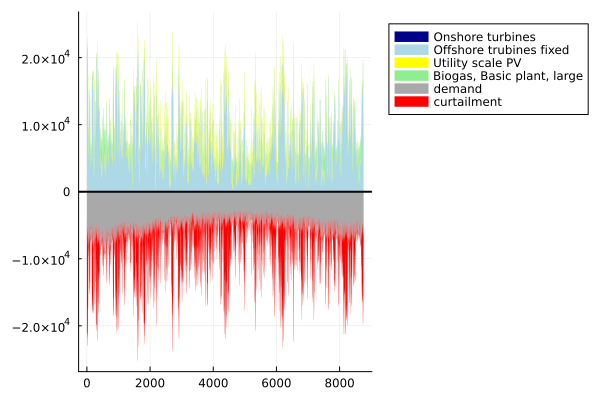

In [164]:

areaplot!(
    balance_plot,
    data_dem,
    label=labels2,
    color=colors2,
    width=0,
    leg=:outertopright
)

hline!(balance_plot, [0], color=:black, label="", width=2)


In [167]:
df_installed_gen = get_result(CAP_G, [:Technology])
x = df_installed_gen[!,:Technology]
y = df_installed_gen[!,:value] ./ 1000

4-element Vector{Float64}:
  0.0
 22.565572574501683
  7.602455655716299
  6.864432850222378

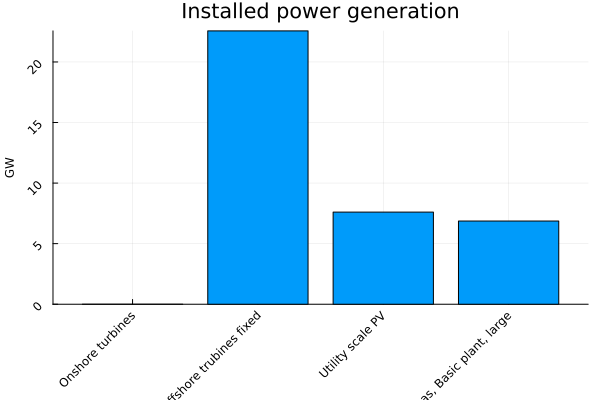

In [168]:
p1 = bar(
    x,
    y,
    leg=false,
    title="Installed power generation",
    ylabel="GW",
    guidefontsize=8,
    rotation=45
)